In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks, savgol_filter
from typing import Pattern

from utils import *

# Parser
COACH_DIR = Path("/Users/hyeon/SeSAC_Project/Coach")    # Coach의 절대경로 입력
RUN_FOLDER = "test14"
RUN_DIR = COACH_DIR / "run" / RUN_FOLDER

# 루트 디렉토리 바로 아래의 pose_predictions.json 지정
OUTPUTS_DIR = RUN_DIR / "outputs"

user = RUN_DIR / "user_info.json"
with user.open(mode="r", encoding='utf-8') as file:
    user_data = json.load(file)

hpe = OUTPUTS_DIR / "pose_predictions.json"
with hpe.open(mode="r", encoding='utf-8') as file:
    pose_data = json.load(file)

details = OUTPUTS_DIR / "details.json"
with details.open(mode="r", encoding='utf-8') as file:
    detail_data = json.load(file)

ps = PoseSequence(pose_data, detail_data, user_data)


In [2]:
ps.cal_stride()
ps.pixel2m()

사용자의 키를 기반으로 계산한 픽셀당 meter는 0.00183993589265602 / pixel 입니다.


np.float64(0.00183993589265602)

In [3]:
# 케이던스

fps = ps.details['video']['fps']
gct_frame = ps.gct()
try:
    if len(gct_frame) > 2:
        start = gct_frame[0][0]
        end = gct_frame[1][0]
    else:
        start = ps.strides.frame.iloc[0]
        end = ps.strides.frame.iloc[4]
    interval = end - start
    m_per_pixel = (ps.pixel2m(frame=start) + ps.pixel2m(frame=end)) / 2
    distance_pixel = ps.df[f'{ps.direction}_heel_x'].loc[[start, end]].diff()[end]
except:
    print("케이던스 검출 불가")


사용자의 키를 기반으로 계산한 픽셀당 meter는 0.0018311304077960966 / pixel 입니다.
사용자의 키를 기반으로 계산한 픽셀당 meter는 0.001847149987775707 / pixel 입니다.


In [4]:
start, end

(np.int64(7), np.int64(46))

In [5]:
time = interval / fps

In [6]:
distance_pixel * m_per_pixel

np.float64(1.6683742921492473)

In [41]:
def cadence_pace(ps: PoseSequence):
    fps = ps.details['video']['fps']
    gct_frame = ps.gct()
    try:
        if len(gct_frame) > 2:
            start = gct_frame[0][0]
            end = gct_frame[1][0]
        else:
            start = ps.strides.frame.iloc[0]
            end = ps.strides.frame.iloc[4]
        interval = end - start
        m_per_pixel = (ps.pixel2m(frame=start) + ps.pixel2m(frame=end)) / 2
        distance_pixel = ps.df[f'{ps.direction}_heel_x'].loc[[start, end]].diff()[end]
    except:
        print("케이던스 검출 불가")
        return None, None


    time = interval / fps
    
    return (2 / time) * 60, (time / (distance_pixel * m_per_pixel) * 1000) / 60

In [7]:
time / (distance_pixel * m_per_pixel) * 1000

np.float64(389.60082462230434)

In [8]:
len(ps.gct()) > 2

False

In [9]:
ps.strides.frame

1     7
2    18
3    28
4    32
1    46
2    57
Name: frame, dtype: int64

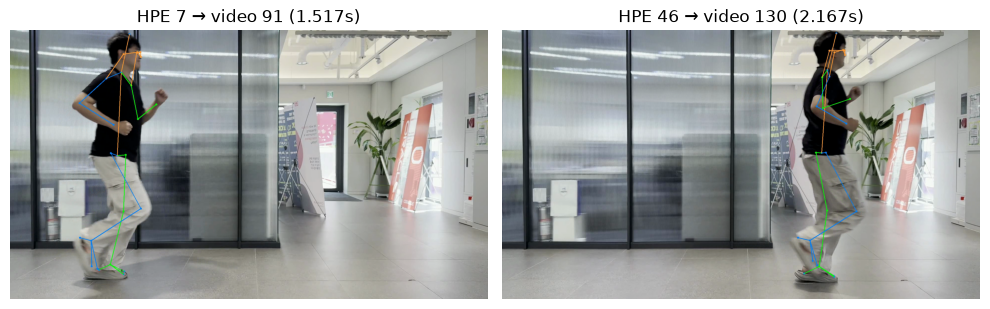

[array([[[146, 159, 159],
         [146, 159, 159],
         [141, 154, 154],
         ...,
         [130, 130, 119],
         [130, 130, 119],
         [130, 130, 119]],
 
        [[146, 159, 159],
         [146, 159, 159],
         [141, 154, 154],
         ...,
         [130, 130, 119],
         [130, 130, 119],
         [130, 130, 119]],
 
        [[145, 158, 158],
         [145, 158, 158],
         [141, 154, 154],
         ...,
         [130, 130, 119],
         [130, 130, 119],
         [130, 130, 119]],
 
        ...,
 
        [[172, 171, 167],
         [171, 169, 166],
         [169, 168, 165],
         ...,
         [134, 136, 131],
         [133, 134, 130],
         [132, 133, 129]],
 
        [[172, 171, 167],
         [172, 171, 167],
         [171, 169, 166],
         ...,
         [133, 134, 130],
         [132, 133, 129],
         [132, 133, 129]],
 
        [[173, 172, 168],
         [173, 172, 168],
         [174, 173, 169],
         ...,
         [134, 136, 131],
  

In [10]:
show_video_frames(
    "/Users/hyeon/SeSAC_Project/Coach/run/test14/outputs/output.mp4",
    frames=[start, end],
    hpe_start_frame=84,
    columns=2
)

In [11]:
m_per_pixel

np.float64(0.0018391401977859018)

In [12]:
time = interval / fps

In [13]:
(2 / time) * 60

np.float64(184.61538461538458)

In [14]:
time

np.float64(0.65)

In [15]:
ps.strides

,frame,value,class
1,7,86.384202,1
2,18,9.953136,0
3,28,33.111829,1
4,32,24.101460,0
1,46,85.720479,1
2,57,8.816819,0


In [16]:
gct_frame

[[27, 37]]

In [17]:
ps.df.columns

Index(['nose_x', 'nose_y', 'left_eye_x', 'left_eye_y', 'right_eye_x',
       'right_eye_y', 'left_ear_x', 'left_ear_y', 'right_ear_x', 'right_ear_y',
       'left_shoulder_x', 'left_shoulder_y', 'right_shoulder_x',
       'right_shoulder_y', 'left_elbow_x', 'left_elbow_y', 'right_elbow_x',
       'right_elbow_y', 'left_wrist_x', 'left_wrist_y', 'right_wrist_x',
       'right_wrist_y', 'left_hip_x', 'left_hip_y', 'right_hip_x',
       'right_hip_y', 'left_knee_x', 'left_knee_y', 'right_knee_x',
       'right_knee_y', 'left_ankle_x', 'left_ankle_y', 'right_ankle_x',
       'right_ankle_y', 'head_x', 'head_y', 'neck_x', 'neck_y', 'hip_center_x',
       'hip_center_y', 'left_big_toe_x', 'left_big_toe_y', 'right_big_toe_x',
       'right_big_toe_y', 'left_small_toe_x', 'left_small_toe_y',
       'right_small_toe_x', 'right_small_toe_y', 'left_heel_x', 'left_heel_y',
       'right_heel_x', 'right_heel_y'],
      dtype='str')

In [18]:
ps.gct()

[[27, 37]]

In [19]:
strides = ps.gct()

# 각 스트라이드별로 골반의 수직 진동 평균
res = 0
for i in range(len(strides)):
    start, end = strides[i]
    res += ps.df["hip_center_y"][start:end].agg(['min', 'max']).diff()['max']
    
# APO: Amplitude of pelvis oscillation : 골반 진동 진폭
apo_pixel = res / len(strides)
d = float(apo_pixel * ps.m_per_pixel / ps.user['height'])

In [20]:
d

0.039619039969438545

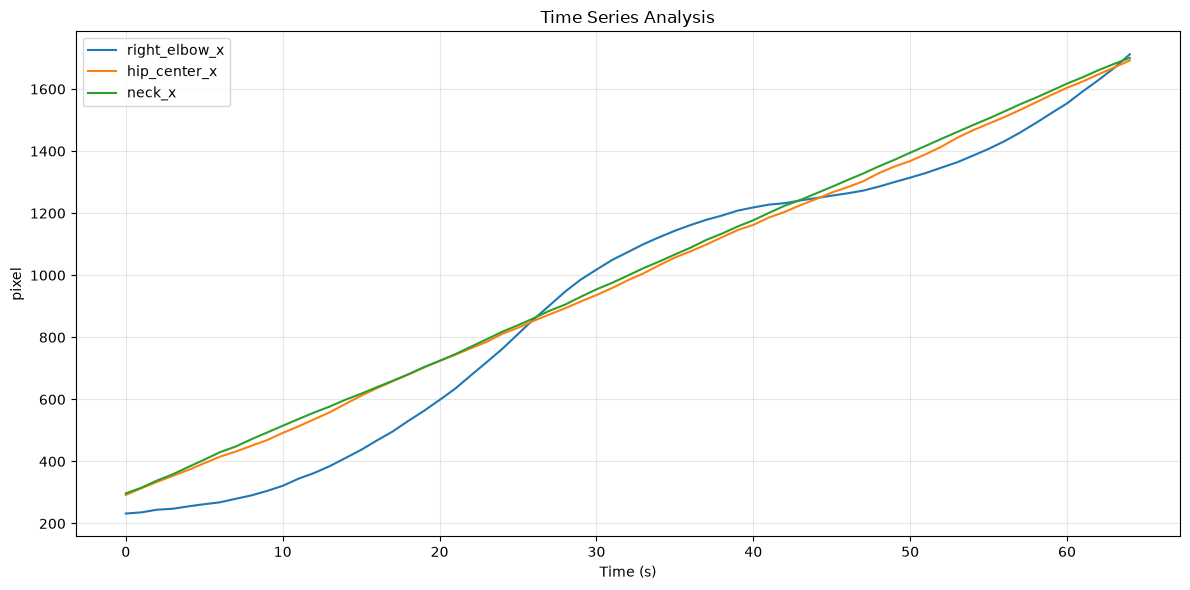

In [21]:
visualize_frame(ps.df[['right_elbow_x', 'hip_center_x', 'neck_x']])

In [22]:
indices = np.where(ps.df['right_elbow_x'] < ps.df[['hip_center_x', 'neck_x']].mean(axis=1))[0]

In [23]:
groups = np.split(
    indices,
    np.where(np.diff(indices) != 1)[0] + 1
)

In [24]:
groups

[array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
        17, 18, 19, 20, 21, 22, 23, 24, 25]),
 array([44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60,
        61, 62, 63])]

In [25]:
for g in groups:
    abs(len(ps.df) - g.mean())

In [26]:
middle_frame = (len(ps.df) - 1) / 2

selected_group = min(
    groups,
    key=lambda group: abs(np.mean(group) - middle_frame)
)

In [27]:
selected_group[-1]

np.int64(25)

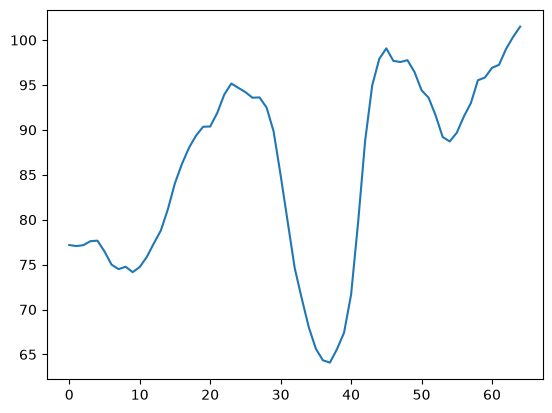

In [28]:
plt.plot(ps.joint_angle("right_elbow", smooth=True))

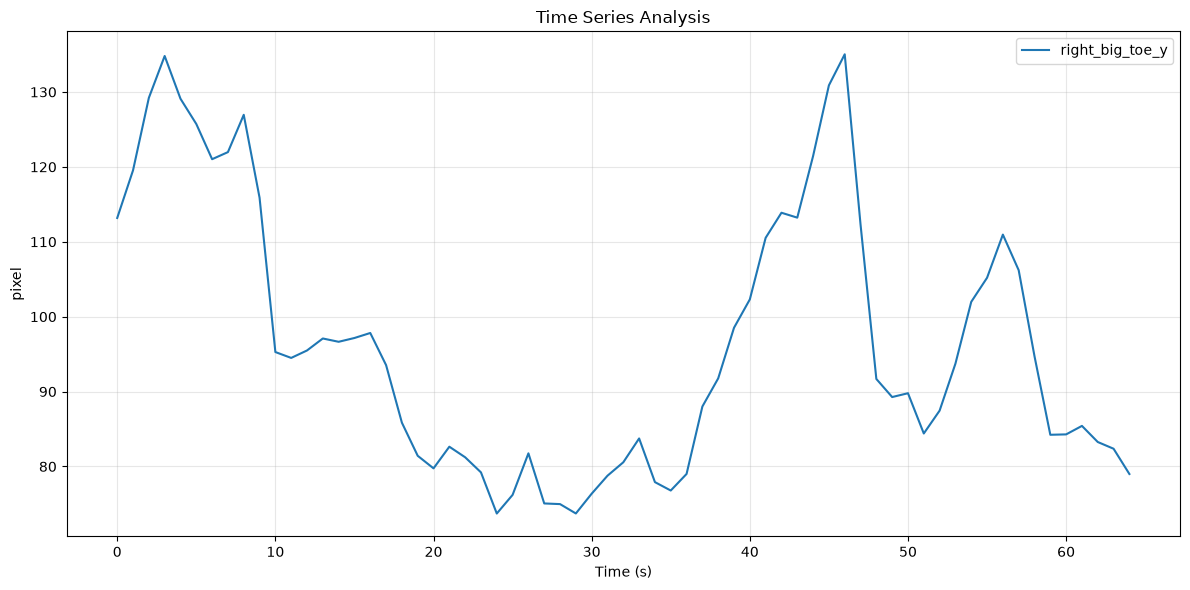

In [29]:
visualize_frame(ps.df['right_big_toe_y'])

In [30]:
ps.strides

,frame,value,class
1,7,86.384202,1
2,18,9.953136,0
3,28,33.111829,1
4,32,24.101460,0
1,46,85.720479,1
2,57,8.816819,0


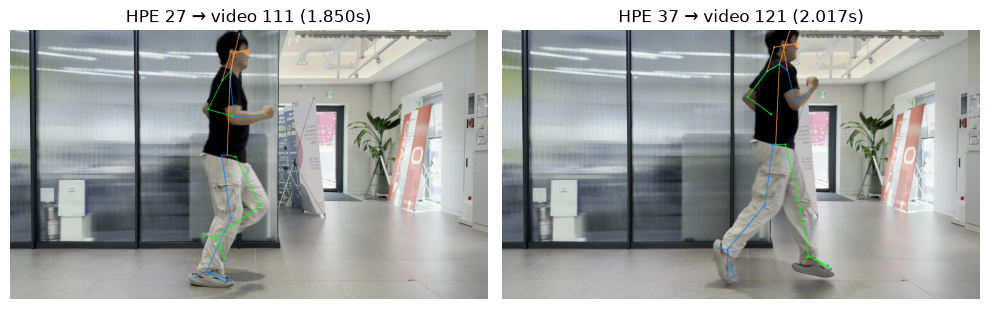

[array([[[152, 158, 162],
         [151, 157, 161],
         [151, 157, 161],
         ...,
         [129, 129, 118],
         [129, 129, 118],
         [129, 129, 118]],
 
        [[150, 155, 160],
         [148, 154, 159],
         [148, 154, 159],
         ...,
         [130, 130, 119],
         [130, 130, 119],
         [130, 130, 119]],
 
        [[147, 153, 158],
         [146, 152, 157],
         [146, 152, 157],
         ...,
         [130, 130, 119],
         [130, 130, 119],
         [130, 130, 119]],
 
        ...,
 
        [[171, 172, 169],
         [169, 171, 168],
         [168, 169, 167],
         ...,
         [138, 139, 134],
         [137, 138, 133],
         [137, 138, 133]],
 
        [[173, 174, 172],
         [172, 173, 171],
         [169, 171, 168],
         ...,
         [137, 138, 133],
         [137, 138, 133],
         [137, 138, 133]],
 
        [[172, 173, 171],
         [172, 173, 171],
         [171, 172, 169],
         ...,
         [137, 138, 133],
  

In [31]:
show_video_frames(
    "/Users/hyeon/SeSAC_Project/Coach/run/test14/outputs/output.mp4",
    [27, 37],
    hpe_start_frame=84,
    columns=2
)

In [32]:
ps.gct()

[[27, 37]]

In [33]:
elbow = ps.joint_angle('left_elbow', smooth=True, negative=False)

In [34]:
elbow

array([ 98.86216477,  88.20001664,  82.89822307,  85.52757935,
        86.65396401,  78.8861289 ,  69.31694999,  61.62635355,
        57.47524129,  53.69491939,  51.98438322,  49.61511812,
        46.03581801,  43.87619548,  44.22898456,  46.42714482,
        49.42778289,  56.23423564,  65.5771768 ,  75.60594427,
        84.48005753,  91.70115994,  98.78971356, 103.12085978,
       110.86471777,  97.47191618,  80.27138717,  80.38960355,
        99.24929577, 104.33216355,  98.36247075,  97.29953057,
        97.82511209,  97.58337303,  96.5145095 ,  94.36467676,
        92.06571904,  89.59328902,  87.59486823,  84.42950553,
        79.48599866,  73.55571047,  74.15448325,  78.30304654,
        83.0098027 ,  79.42500021,  75.30787026,  70.09053677,
        67.9404288 ,  67.18490355,  68.1413225 ,  68.53091107,
        64.29602446,  60.73969033,  58.5627591 ,  61.84825904,
        66.38360793,  71.39589174,  76.17674054,  83.73331837,
        89.40316396,  87.54100059, 104.99042905, 100.52

In [35]:
elbow.max()

np.float64(110.86471777486646)

In [36]:
len(elbow)

65

In [37]:
len(ps.df)

65

In [38]:
distance = ps.details["video"]['fps'] // 6